# L4 BMD & Microarchitecture — *Practical Pipeline v3 (YOLOv8-seg)*

### *"The measurement of spinal bone architecture following hip surgery using X-ray datasets"*

A **practical, measurement-focused** pipeline. The L4 vertebra is segmented with the
**YOLOv8-seg** instance model (the most reliable L4 extractor in our experiments — instance
detection naturally resolves *which* vertebra is L4 and recovers it via a top→bottom fallback),
and the same **measurement science** as v2 is layered on top:

- **Bone Mineral Density (BMD)** — area-based density index from the *linear* (uncorrected)
  normalized intensity inside the predicted L4 ROI.
- **Bone Microarchitecture** — GLCM texture descriptors (Contrast, Correlation, Energy/ASM,
  Homogeneity) of the L4 trabecular region.
- **Evaluation** against the DICOM test ground-truth L4 masks (Dice / IoU / Precision / Recall,
  confusion matrix, Bland–Altman BMD agreement).
- **XAI** — an **L4-localized Eigen-CAM** that, unlike a deep-bottleneck Grad-CAM, places the
  attribution heatmap on the L4 body and its trabecular structure.

> Design note: segmentation is a **swappable module**. We use YOLOv8-seg here because it gives the
> best L4 masks; the BMD/GLCM/eval/XAI code is segmenter-agnostic. (A from-scratch ResNet-U-Net
> variant lives in `L4_AP_segmentation_v2.ipynb`.)

> ⚠️ **Clinical caveat.** Planar-radiograph "density" is an *uncorrected radiological proxy*
> (pixel intensity), **not** true areal BMD (g/cm²). Absolute BMD needs DXA/QCT or an in-image
> calibration phantom. Values below are relative indices for methodological demonstration.

## 1. Clinical Definitions & Mathematical Formulation

### 1.1 Bone Mineral Density (BMD) — area-based intensity proxy
With the X-ray linearly normalized to $[0,1]$ and $\Omega_{L4}$ the predicted L4 ROI:
$$\text{BMD}_{\text{index}}=\frac{1}{|\Omega_{L4}|}\sum_{(x,y)\in\Omega_{L4}} I_{\text{norm}}(x,y),
\qquad I_{\text{norm}}=\frac{I-I_{\min}}{I_{\max}-I_{\min}}.$$
We use the **linear** (CLAHE-free) intensity for BMD so the density meaning is preserved, and report
median / std / p10 / p90 for distribution robustness.

### 1.2 Microarchitecture — Gray-Level Co-occurrence Matrix (GLCM)
Quantising the ROI to $L=32$ levels and averaging $P_\delta$ over
$\theta\in\{0,45,90,135^\circ\}$ at $d=1$:
$$\textbf{Contrast}=\sum_{i,j}(i-j)^2P(i,j),\quad \textbf{Energy/ASM}=\sum_{i,j}P(i,j)^2,$$
$$\textbf{Correlation}=\sum_{i,j}\frac{(i-\mu_i)(j-\mu_j)P(i,j)}{\sigma_i\sigma_j},\quad
\textbf{Homogeneity}=\sum_{i,j}\frac{P(i,j)}{1+|i-j|}.$$
Dense trabecular bone ⇒ high Energy/Homogeneity, low Contrast; disrupted/osteoporotic bone ⇒ higher
Contrast, lower Correlation.

## 0. Environment & Imports

Target: **Windows + RTX 5060 Laptop (CUDA)**. Requires `ultralytics` (YOLOv8). Uncomment to install.

In [1]:
# !pip install ultralytics pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg \
# !             opencv-python-headless scikit-image scikit-learn matplotlib seaborn pandas

import os, glob, re, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
random.seed(42); np.random.seed(42)
print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


## 2. Configuration & Paths

In [2]:
# -------------------- Paths --------------------
BUU_ROOT      = "./BUU-LSPINE-2000/AP"
IMG_DIR       = os.path.join(BUU_ROOT, "images")
LBL_DIR       = os.path.join(BUU_ROOT, "labels")
TEST_DCM_DIR  = "./dataset-dcm/test/gather"
TEST_MASK_DIR = "./dataset-dcm/test/gather_mask/SegmentationClass"   # L4 ground-truth (PNG)
OUT_DIR       = "./l4_v3_output"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------- Model --------------------
YOLO_WEIGHTS = "./runs/segment/ap_seg/l1_l5/weights/best.pt"   # trained YOLOv8-seg (L1..L5)
CONF         = 0.25

# -------------------- Task --------------------
CLASS_NAMES = ["L1", "L2", "L3", "L4", "L5"]
L4_IDX      = CLASS_NAMES.index("L4")    # = 3
GLCM_LEVELS = 32
ROI_SHRINK  = 0.85                       # shrink mask toward centre -> cancellous-bone ROI

assert os.path.exists(YOLO_WEIGHTS), f"YOLO weights not found: {YOLO_WEIGHTS}\n" \
       "Train first (see optional appendix) or fix the path."
print("Weights:", YOLO_WEIGHTS)

Weights: ./runs/segment/ap_seg/l1_l5/weights/best.pt


### Image loaders (JPG / DICOM)

Each loader returns **two views** from one X-ray:
- `rgb_uint8` — a display-normalized 3-channel image **fed to YOLO** (matches its training tone:
  bright bone, percentile-windowed; MONOCHROME1 DICOMs are inverted).
- `gray_lin` — a **linear** min–max normalized grayscale used for **BMD/GLCM** (no CLAHE, so the
  density meaning is preserved).

In [3]:
def load_xray(path):
    '''Return (rgb_uint8 for YOLO, gray_lin float[0,1] for BMD/GLCM, H, W).'''
    ext = os.path.splitext(path)[1].lower()
    if ext == ".dcm":
        import pydicom
        ds  = pydicom.dcmread(path)
        raw = ds.pixel_array.astype(np.float32)
        raw = raw * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            raw = raw.max() - raw                      # bright bone, linear
        lo, hi = np.percentile(raw, 0.5), np.percentile(raw, 99.5)
        if hi <= lo:
            lo, hi = raw.min(), raw.max() + 1e-6
        rgb = cv2.cvtColor((np.clip((raw - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8),
                           cv2.COLOR_GRAY2RGB)
        gray_lin = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)
        H, W = raw.shape
        return rgb, gray_lin.astype(np.float32), H, W
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    gray_lin = (g.astype(np.float32) - g.min()) / (g.max() - g.min() + 1e-6)
    return rgb, gray_lin, g.shape[0], g.shape[1]

def list_pairs():
    pairs = []
    for lp in sorted(glob.glob(os.path.join(LBL_DIR, "*"))):
        stem = os.path.splitext(os.path.basename(lp))[0]
        for ext in (".jpg", ".jpeg", ".png"):
            ip = os.path.join(IMG_DIR, stem + ext)
            if os.path.exists(ip):
                pairs.append(ip); break
    return pairs

buu_imgs      = list_pairs()
test_dcm_files = sorted(glob.glob(os.path.join(TEST_DCM_DIR, "*.dcm")))
eval_items = [p for p in test_dcm_files
              if os.path.exists(os.path.join(TEST_MASK_DIR,
                 os.path.splitext(os.path.basename(p))[0] + ".png"))]
print(f"BUU images: {len(buu_imgs)} | DICOM test: {len(test_dcm_files)} "
      f"({len(eval_items)} with L4 ground truth)")

BUU images: 400 | DICOM test: 42 (42 with L4 ground truth)


## Step 1 — Data Loading (visualization)

Sample raw X-rays with their intensity histograms.

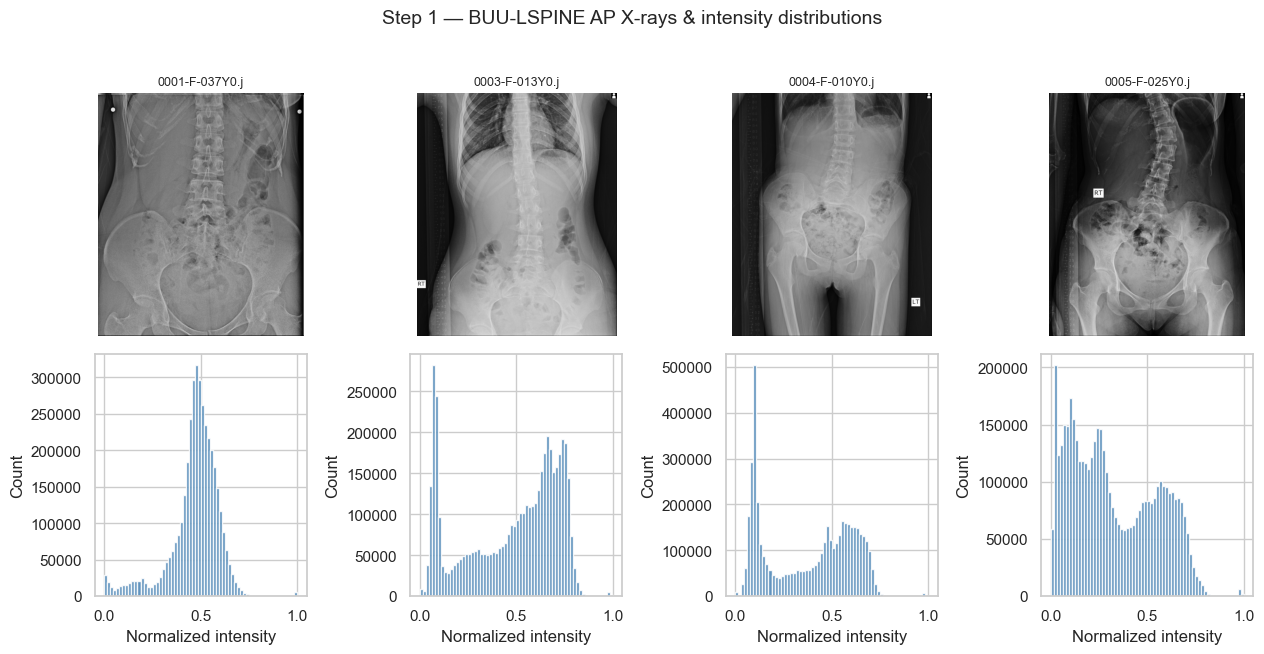

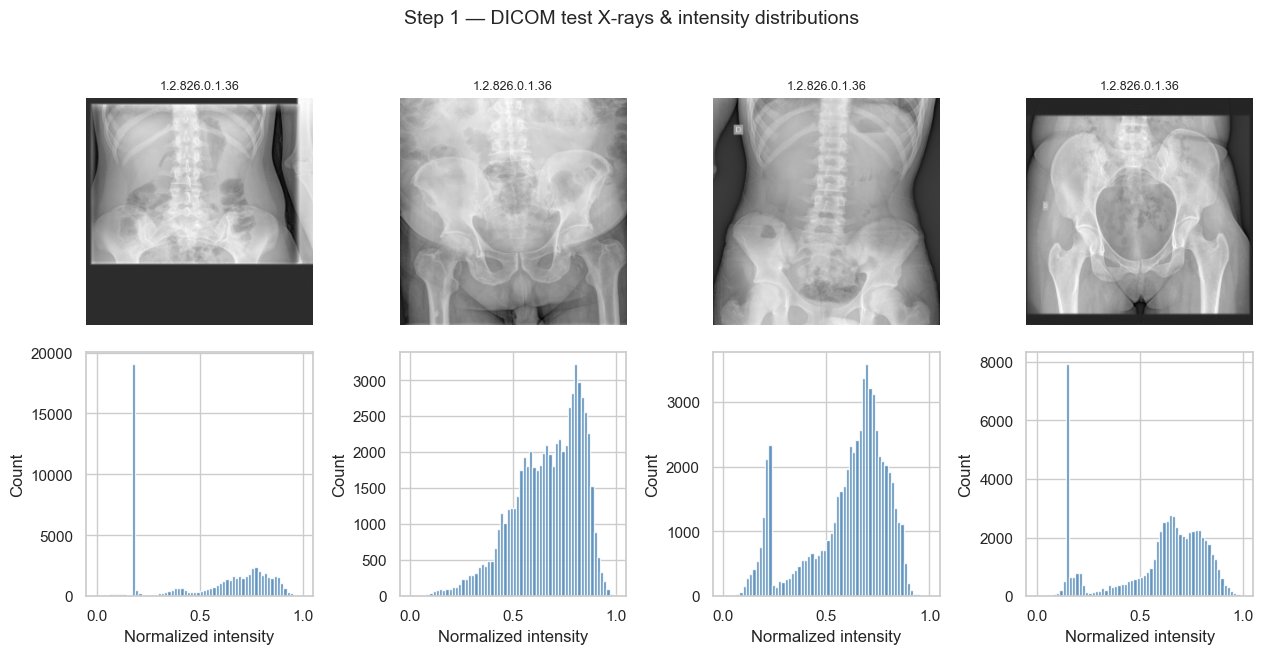

In [4]:
def show_raw_with_histograms(paths, title):
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.4))
    for k, p in enumerate(paths):
        _, g, _, _ = load_xray(p)
        axes[0, k].imshow(g, cmap="gray"); axes[0, k].set_title(os.path.basename(p)[:14], fontsize=9)
        axes[0, k].axis("off")
        axes[1, k].hist(g.ravel(), bins=64, color="steelblue", alpha=0.85)
        axes[1, k].set_xlabel("Normalized intensity"); axes[1, k].set_ylabel("Count")
    fig.suptitle(title, fontsize=14, y=1.02); plt.tight_layout(); plt.show()

show_raw_with_histograms(buu_imgs[:4], "Step 1 — BUU-LSPINE AP X-rays & intensity distributions")
if eval_items:
    show_raw_with_histograms(eval_items[:4], "Step 1 — DICOM test X-rays & intensity distributions")

## Step 2 — Load YOLOv8-seg & Robust L4 Extraction

The trained model detects L1–L5 as instances. The L4 mask is chosen by **class** when available,
else by the **4th-from-top** rule (vertebrae ordered by vertical centroid) — so L4 is essentially
never dropped. The polygon is rasterised to a binary mask at the image's native resolution.

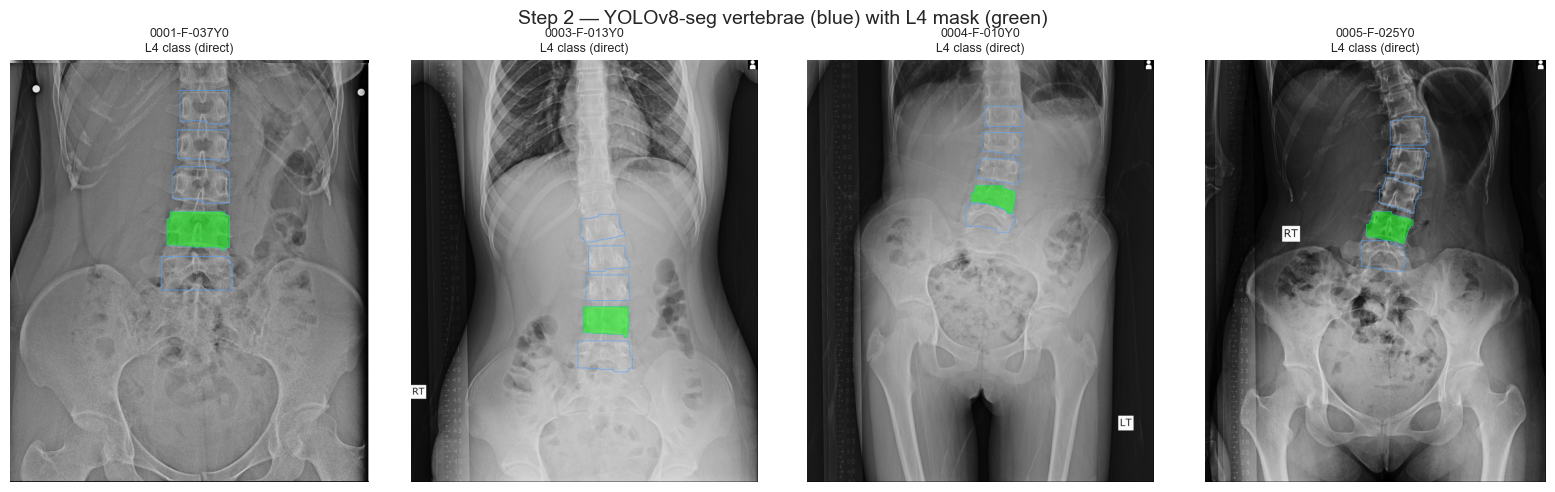

In [5]:
seg = YOLO(YOLO_WEIGHTS)

def poly_to_mask(poly_xy, H, W, shrink=1.0):
    poly = np.asarray(poly_xy, np.float32)
    if shrink != 1.0 and len(poly):
        ctr = poly.mean(0); poly = ctr + shrink * (poly - ctr)
    m = np.zeros((H, W), np.uint8)
    if len(poly):
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
    return m

def pick_l4_index(boxes_xyxy, classes, confs):
    '''Choose the L4 instance: direct class, else 4th vertebra from the top (fallback).'''
    if len(boxes_xyxy) == 0:
        return None, "no detection"
    idx = [i for i, c in enumerate(classes) if c == L4_IDX]
    if idx:
        return max(idx, key=lambda i: confs[i]), "L4 class (direct)"
    order = sorted(range(len(boxes_xyxy)), key=lambda i: (boxes_xyxy[i][1] + boxes_xyxy[i][3]) / 2)
    if len(order) >= 4:
        return order[3], "4th-from-top (fallback)"
    return None, f"only {len(boxes_xyxy)} vertebrae"

def yolo_l4(rgb, conf=CONF, shrink=1.0):
    '''Run YOLO and return (l4_mask[H,W] or None, status, result).'''
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    if r.masks is None or len(r.boxes) == 0:
        return None, "no detection", r
    boxes = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()
    i, status = pick_l4_index(boxes, classes, confs)
    if i is None:
        return None, status, r
    return poly_to_mask(r.masks.xy[i], H, W, shrink), status, r

# ---- Visualization: YOLO segmentation with L4 highlighted ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for k, p in enumerate(buu_imgs[:4]):
    rgb, _, H, W = load_xray(p)
    m, status, r = yolo_l4(rgb)
    vis = rgb.copy()
    if r.masks is not None:
        for poly in r.masks.xy:
            cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
    if m is not None:
        vis[m > 0] = (0.5 * vis[m > 0] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    axes[k].imshow(vis); axes[k].set_title(f"{os.path.basename(p)[:12]}\n{status}", fontsize=9)
    axes[k].axis("off")
fig.suptitle("Step 2 — YOLOv8-seg vertebrae (blue) with L4 mask (green)", fontsize=14)
plt.tight_layout(); plt.show()

## Step 3 — BMD & GLCM Extractors

In [6]:
def shrink_mask(mask, shrink=ROI_SHRINK):
    if shrink >= 1.0:
        return mask
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return mask
    cx, cy = xs.mean(), ys.mean()
    out = np.zeros_like(mask)
    nx = np.clip((cx + shrink * (xs - cx)).astype(int), 0, mask.shape[1] - 1)
    ny = np.clip((cy + shrink * (ys - cy)).astype(int), 0, mask.shape[0] - 1)
    out[ny, nx] = 1
    return cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

def compute_bmd(img_norm, mask):
    vals = img_norm[mask > 0]
    if vals.size == 0:
        return None
    return {"area_px": int(vals.size), "bmd_mean": float(vals.mean()),
            "bmd_median": float(np.median(vals)), "bmd_std": float(vals.std()),
            "bmd_p10": float(np.percentile(vals, 10)), "bmd_p90": float(np.percentile(vals, 90))}

def compute_glcm(img_norm, mask, levels=GLCM_LEVELS):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    roi  = (img_norm[y0:y1, x0:x1] * (levels - 1)).astype(np.uint8)
    mroi = mask[y0:y1, x0:x1]
    roi[mroi == 0] = 0
    glcm = graycomatrix(roi, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)
    return {"glcm_contrast": float(graycoprops(glcm, "contrast").mean()),
            "glcm_correlation": float(graycoprops(glcm, "correlation").mean()),
            "glcm_energy": float(graycoprops(glcm, "energy").mean()),
            "glcm_homogeneity": float(graycoprops(glcm, "homogeneity").mean())}

def load_test_gt_l4(dcm_path, H, W):
    '''Binary L4 ground-truth mask (PNG) resized to (H, W).'''
    stem = os.path.splitext(os.path.basename(dcm_path))[0]
    p = os.path.join(TEST_MASK_DIR, stem + ".png")
    if not os.path.exists(p):
        return None
    m = cv2.imread(p)
    fg = (m.sum(axis=2) > 10).astype(np.uint8)
    return cv2.resize(fg, (W, H), interpolation=cv2.INTER_NEAREST)
print("Helpers ready.")

Helpers ready.


## Step 4 — Evaluation on the DICOM Test Set

The trained model is evaluated on `dataset-dcm/test/gather` against the **L4 ground-truth masks**.
Reported: **Dice / IoU / Precision / Recall**, a pixel **confusion matrix**, predicted-vs-GT
**overlays**, and a **Bland–Altman + correlation** of BMD measured in the predicted vs ground-truth
L4 mask.

In [ ]:
def seg_scores(pred, gt, eps=1e-6):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    dice = 2*tp / (2*tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec = tp / (tp + fn + eps)
    return dice, iou, prec, rec, int(tp), int(fp), int(fn)

rows, bmd_pred, bmd_gt = [], [], []
cm_total = np.zeros((2, 2), dtype=np.int64)
n_fail = 0
for dp in eval_items:
    rgb, gray_lin, H, W = load_xray(dp)
    m, status, r = yolo_l4(rgb)
    gt = load_test_gt_l4(dp, H, W)
    if gt is None:
        continue
    if m is None:
        m = np.zeros((H, W), np.uint8); n_fail += 1
    d, i, p, rc, tp, fp, fn = seg_scores(m, gt)
    tn = H*W - (tp + fp + fn)
    cm_total += np.array([[tn, fp], [fn, tp]], dtype=np.int64)
    rows.append({"file": os.path.basename(dp), "status": status,
                 "dice": d, "iou": i, "precision": p, "recall": rc})
    bp = compute_bmd(gray_lin, shrink_mask(m)) if m.sum() else None
    bg = compute_bmd(gray_lin, shrink_mask(gt))
    if bp and bg:
        bmd_pred.append(bp["bmd_mean"]); bmd_gt.append(bg["bmd_mean"])

dfm = pd.DataFrame(rows)
print(f"Evaluated {len(dfm)} test images | L4 detection failures: {n_fail}")
print("\n=== L4 segmentation metrics (mean +/- std) ===")
for c in ["dice", "iou", "precision", "recall"]:
    print(f"  {c.capitalize():10s}: {dfm[c].mean():.4f} +/- {dfm[c].std():.4f}")
dfm.to_csv(os.path.join(OUT_DIR, "L4_test_segmetrics.csv"), index=False)

Evaluated 42 test images | L4 detection failures: 2

=== L4 segmentation metrics (mean +/- std) ===
  Dice      : 0.2788 +/- 0.4056
  Iou       : 0.2453 +/- 0.3634
  Precision : 0.2767 +/- 0.4058
  Recall    : 0.2834 +/- 0.4106


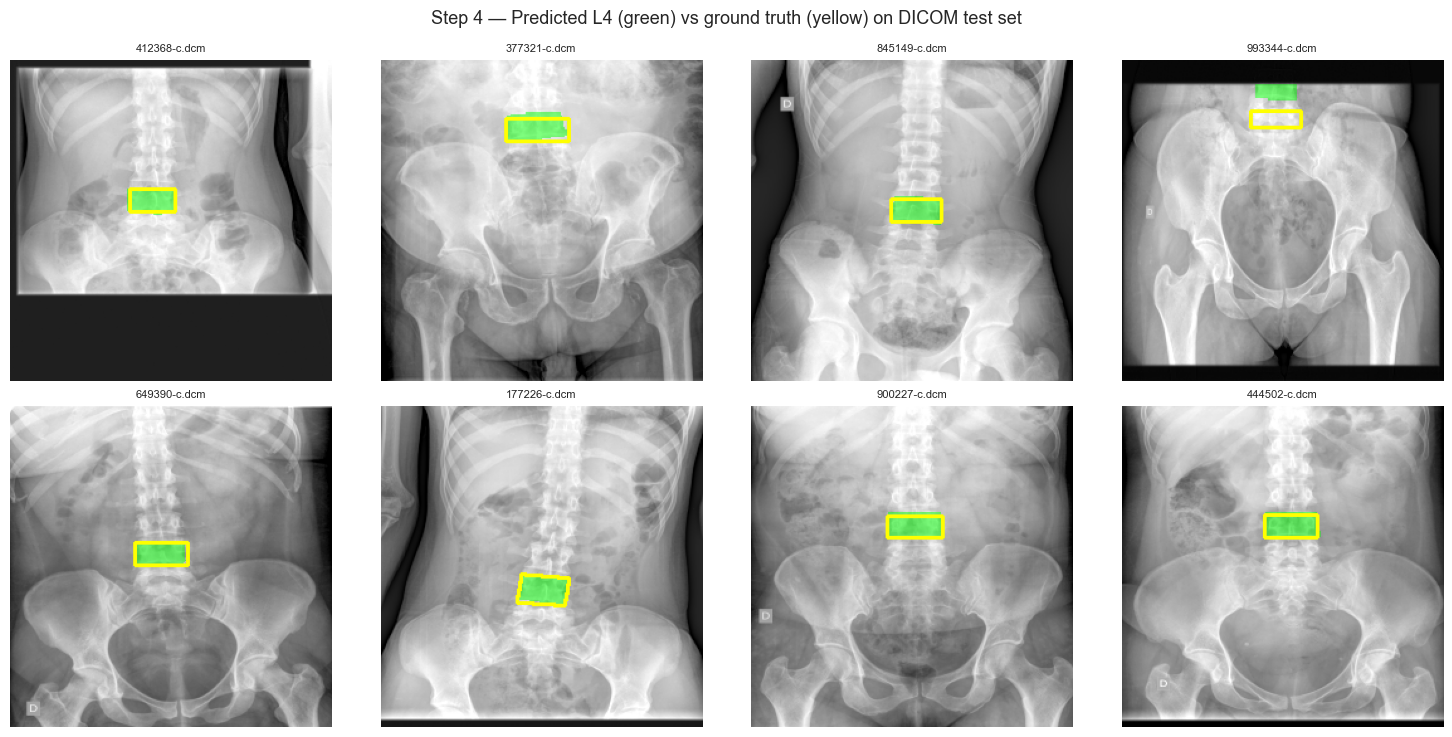

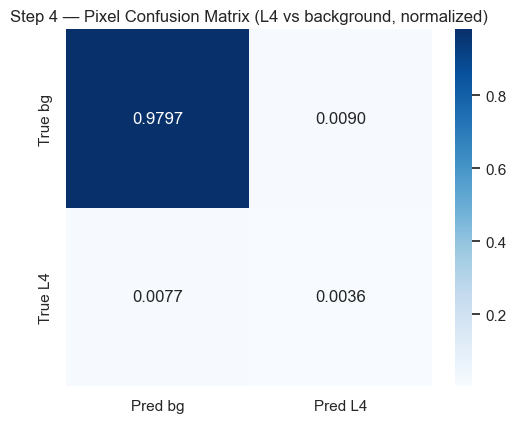

In [8]:
# ---- Overlays: predicted (green) vs ground truth (yellow) ----
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for k, dp in enumerate(eval_items[:8]):
    rgb, _, H, W = load_xray(dp)
    m, status, r = yolo_l4(rgb)
    gt = load_test_gt_l4(dp, H, W)
    vis = rgb.copy()
    if m is not None:
        vis[m > 0] = (0.5*vis[m > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
    if gt is not None:
        cnts, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, cnts, -1, (255, 255, 0), 2)
    ax = axes[k//4, k % 4]
    ax.imshow(vis); ax.set_title(os.path.basename(dp)[-12:], fontsize=8); ax.axis("off")
fig.suptitle("Step 4 — Predicted L4 (green) vs ground truth (yellow) on DICOM test set", fontsize=13)
plt.tight_layout(); plt.show()

# ---- Pixel confusion matrix ----
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm_total / cm_total.sum(), annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Pred bg", "Pred L4"], yticklabels=["True bg", "True L4"], ax=ax)
ax.set_title("Step 4 — Pixel Confusion Matrix (L4 vs background, normalized)")
plt.tight_layout(); plt.show()

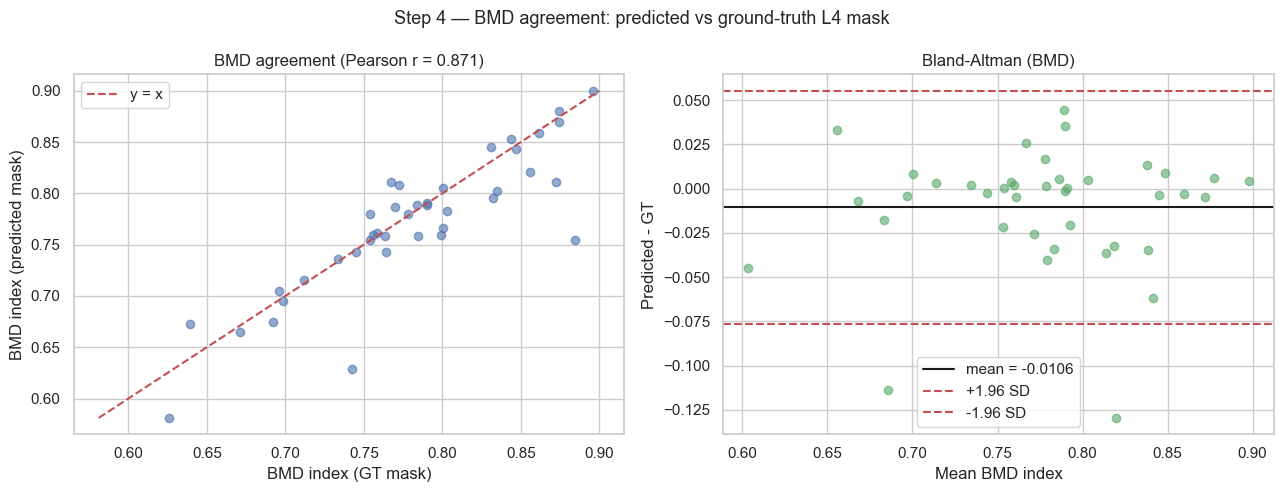

In [9]:
# ---- Bland-Altman + correlation of BMD (predicted vs GT mask) ----
bmd_pred = np.array(bmd_pred); bmd_gt = np.array(bmd_gt)
if len(bmd_gt) >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].scatter(bmd_gt, bmd_pred, alpha=0.6, color="#4C72B0")
    lims = [min(bmd_gt.min(), bmd_pred.min()), max(bmd_gt.max(), bmd_pred.max())]
    ax[0].plot(lims, lims, "r--", label="y = x")
    r = np.corrcoef(bmd_gt, bmd_pred)[0, 1]
    ax[0].set_title(f"BMD agreement (Pearson r = {r:.3f})")
    ax[0].set_xlabel("BMD index (GT mask)"); ax[0].set_ylabel("BMD index (predicted mask)"); ax[0].legend()
    mean_b = (bmd_pred + bmd_gt) / 2.0; diff_b = bmd_pred - bmd_gt
    mdv, sdv = diff_b.mean(), diff_b.std()
    ax[1].scatter(mean_b, diff_b, alpha=0.6, color="#55A868")
    ax[1].axhline(mdv, color="k", label=f"mean = {mdv:.4f}")
    ax[1].axhline(mdv + 1.96*sdv, color="r", ls="--", label="+1.96 SD")
    ax[1].axhline(mdv - 1.96*sdv, color="r", ls="--", label="-1.96 SD")
    ax[1].set_xlabel("Mean BMD index"); ax[1].set_ylabel("Predicted - GT")
    ax[1].set_title("Bland-Altman (BMD)"); ax[1].legend()
    fig.suptitle("Step 4 — BMD agreement: predicted vs ground-truth L4 mask", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("Not enough paired BMD samples for a Bland-Altman plot.")

## Step 5 — Modular Inference (pre-trained model)

`infer_l4(path)` accepts any raw X-ray (**JPG/PNG or DICOM**), runs YOLO segmentation, and returns +
plots the **L4 BMD and GLCM** metrics.

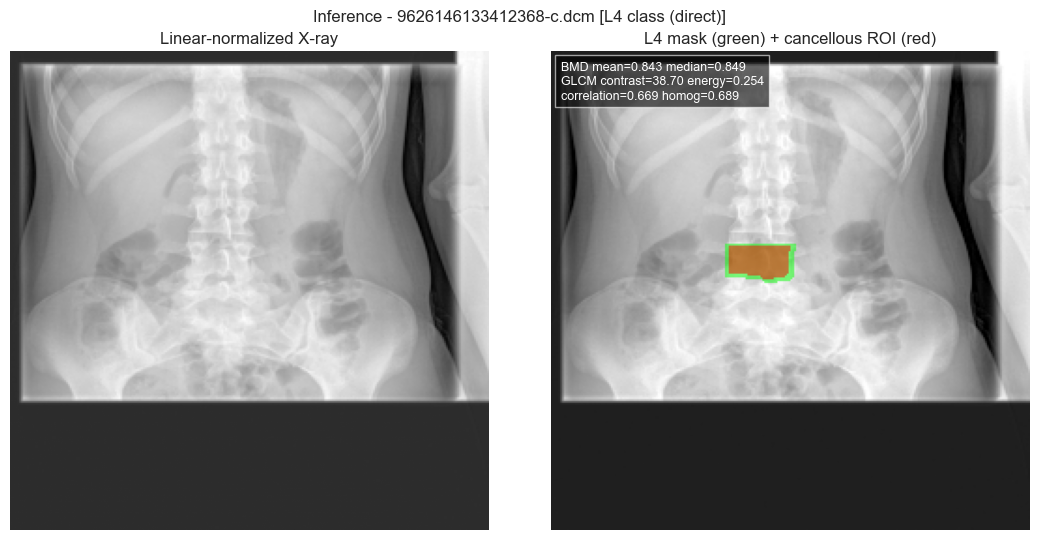

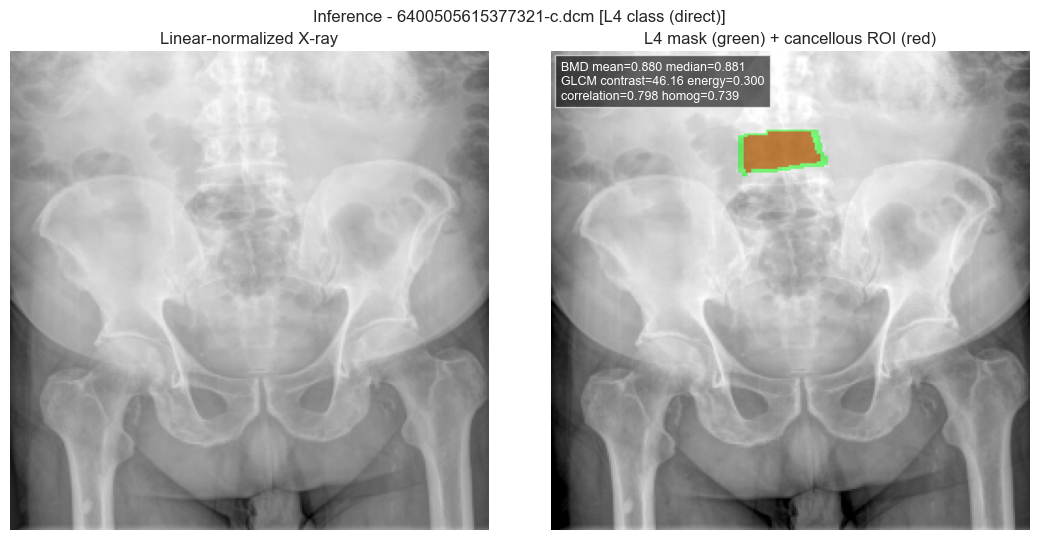

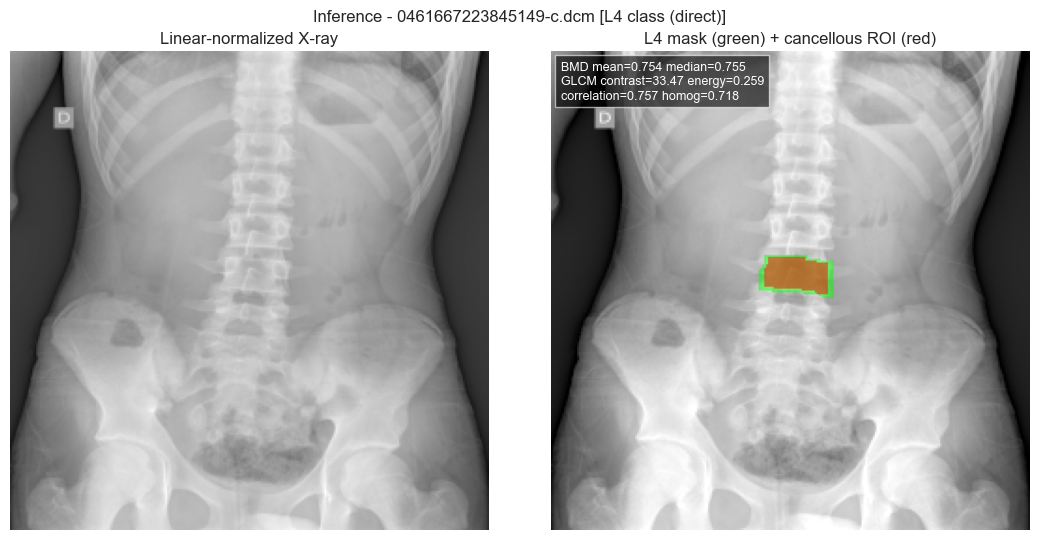

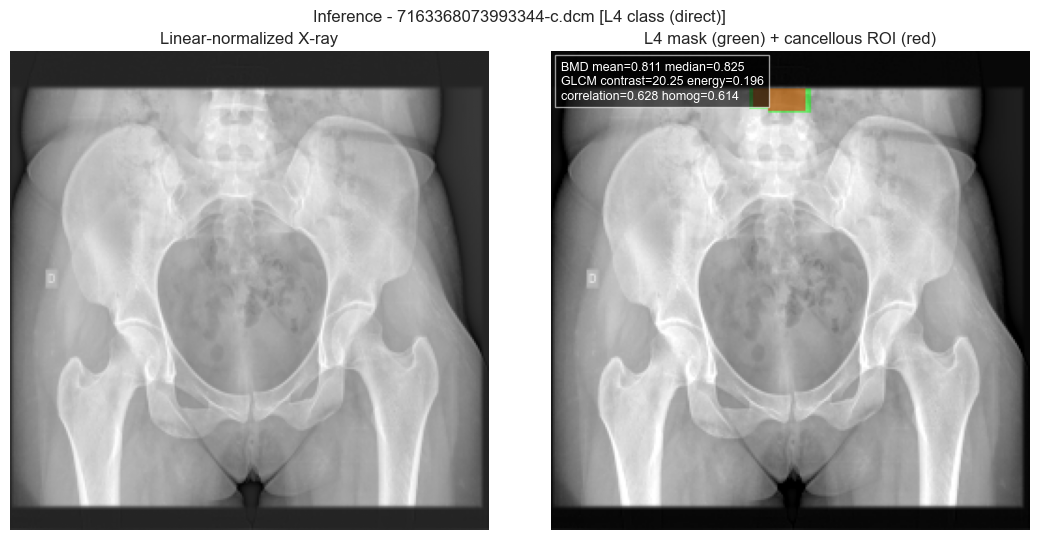

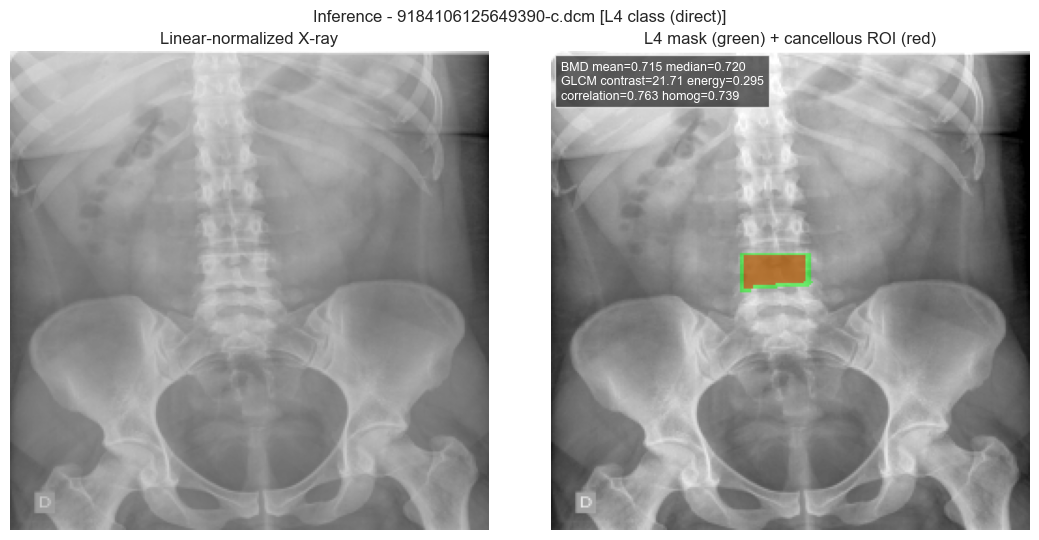

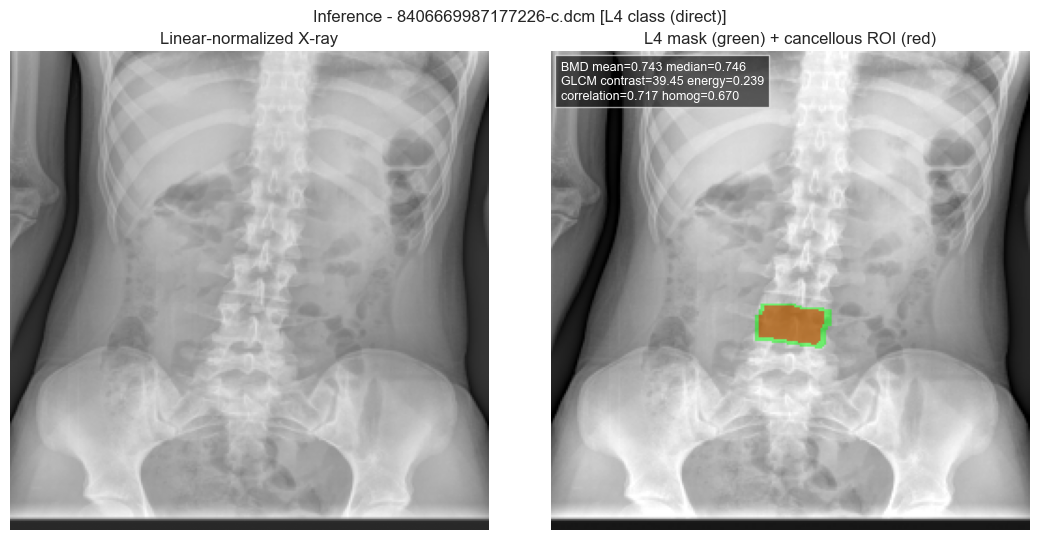

Saved metrics for 42 images -> ./l4_v3_output\L4_test_metrics.csv


,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),523.0,0.843422,0.849016,0.046264,0.784662,0.896339,38.698216,0.668770,0.253585,0.688850
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,L4 class (direct),702.0,0.880302,0.880947,0.032723,0.838859,0.921574,46.160300,0.798313,0.300195,0.738608
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),560.0,0.754180,0.754922,0.043468,0.693177,0.811456,33.470446,0.757155,0.258676,0.718445
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),320.0,0.810675,0.824580,0.075438,0.721076,0.893337,20.248337,0.627842,0.195870,0.613695
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),521.0,0.715132,0.719706,0.039422,0.656048,0.763232,21.705706,0.763090,0.295484,0.739407
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),595.0,0.742523,0.745762,0.051557,0.660379,0.802537,39.449776,0.717295,0.239170,0.669932
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),677.0,0.805560,0.813828,0.054791,0.723028,0.872858,11.525174,0.708874,0.221687,0.682027
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),603.0,0.735561,0.737562,0.058420,0.656769,0.813427,11.126030,0.704694,0.190471,0.606660
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,L4 class (direct),386.0,0.807679,0.810214,0.048106,0.744860,0.866923,27.188929,0.259515,0.243126,0.642237
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),523.0,0.790730,0.793892,0.062030,0.710406,0.867439,2.543152,0.732646,0.205566,0.629842


In [10]:
def infer_l4(path, show=True):
    rgb, gray_lin, H, W = load_xray(path)
    m, status, r = yolo_l4(rgb)
    metrics = {"file": os.path.basename(path), "status": status}
    if m is None or m.sum() == 0:
        if show:
            plt.figure(figsize=(5, 5)); plt.imshow(rgb); plt.title(f"{status} (no L4)"); plt.axis("off"); plt.show()
        return metrics
    roi = shrink_mask(m)
    bmd = compute_bmd(gray_lin, roi); glcm = compute_glcm(gray_lin, roi)
    if bmd:  metrics.update(bmd)
    if glcm: metrics.update(glcm)
    if show:
        vis = rgb.copy()
        vis[m > 0]   = (0.5*vis[m > 0]   + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        vis[roi > 0] = (0.5*vis[roi > 0] + 0.5*np.array([255, 0, 0])).astype(np.uint8)
        fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
        ax[0].imshow(gray_lin, cmap="gray"); ax[0].set_title("Linear-normalized X-ray"); ax[0].axis("off")
        ax[1].imshow(vis); ax[1].axis("off"); ax[1].set_title("L4 mask (green) + cancellous ROI (red)")
        if bmd and glcm:
            txt = (f"BMD mean={bmd['bmd_mean']:.3f} median={bmd['bmd_median']:.3f}\n"
                   f"GLCM contrast={glcm['glcm_contrast']:.2f} energy={glcm['glcm_energy']:.3f}\n"
                   f"correlation={glcm['glcm_correlation']:.3f} homog={glcm['glcm_homogeneity']:.3f}")
            ax[1].text(0.02, 0.98, txt, transform=ax[1].transAxes, va="top", fontsize=9,
                       color="white", bbox=dict(facecolor="black", alpha=0.6))
        fig.suptitle(f"Inference - {os.path.basename(path)[-22:]} [{status}]", fontsize=12)
        plt.tight_layout(); plt.show()
    return metrics

results = [infer_l4(p, show=(k < 6)) for k, p in enumerate(eval_items)]
res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUT_DIR, "L4_test_metrics.csv"), index=False)
print(f"Saved metrics for {len(res_df)} images -> {os.path.join(OUT_DIR, 'L4_test_metrics.csv')}")
display(res_df.head(10))

## Step 6 — Save Spine/L4 Extraction Results for the Test Set

Every DICOM test image is processed and its extraction artifacts are written to
`./l4_v3_output/segmentation/`:
- `<id>_overlay.png` — all detected vertebrae (blue) with the L4 mask (green),
- `<id>_L4mask.png` — the binary L4 mask,
- `L4_extraction_summary.csv` — per-image status + BMD + GLCM metrics.

In [11]:
SEG_DIR = os.path.join(OUT_DIR, "segmentation")
os.makedirs(SEG_DIR, exist_ok=True)

save_rows = []
for dp in test_dcm_files:
    stem = os.path.splitext(os.path.basename(dp))[0]
    rgb, gray_lin, H, W = load_xray(dp)
    m, status, r = yolo_l4(rgb)
    rec = {"file": os.path.basename(dp), "status": status}
    if m is not None and m.sum() > 0:
        roi  = shrink_mask(m)
        bmd  = compute_bmd(gray_lin, roi)
        glcm = compute_glcm(gray_lin, roi)
        if bmd:  rec.update(bmd)
        if glcm: rec.update(glcm)
        vis = rgb.copy()
        if r.masks is not None:
            for poly in r.masks.xy:
                cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
        vis[m > 0] = (0.5*vis[m > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_overlay.png"), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_L4mask.png"), (m * 255).astype(np.uint8))
    save_rows.append(rec)

summary = pd.DataFrame(save_rows)
summary.to_csv(os.path.join(SEG_DIR, "L4_extraction_summary.csv"), index=False)
n_ok = int((summary["status"].astype(str).str.contains("L4")).sum() +
           (summary["status"].astype(str).str.contains("4th")).sum())
print(f"Saved {len(summary)} results to {SEG_DIR} "
      f"(overlay+mask images + L4_extraction_summary.csv); L4 found in {n_ok}/{len(summary)}.")
display(summary.head(10))

Saved 42 results to ./l4_v3_output\segmentation (overlay+mask images + L4_extraction_summary.csv); L4 found in 40/42.


,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),523.0,0.843422,0.849016,0.046264,0.784662,0.896339,38.698216,0.668770,0.253585,0.688850
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,L4 class (direct),702.0,0.880302,0.880947,0.032723,0.838859,0.921574,46.160300,0.798313,0.300195,0.738608
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),560.0,0.754180,0.754922,0.043468,0.693177,0.811456,33.470446,0.757155,0.258676,0.718445
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),320.0,0.810675,0.824580,0.075438,0.721076,0.893337,20.248337,0.627842,0.195870,0.613695
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),521.0,0.715132,0.719706,0.039422,0.656048,0.763232,21.705706,0.763090,0.295484,0.739407
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),595.0,0.742523,0.745762,0.051557,0.660379,0.802537,39.449776,0.717295,0.239170,0.669932
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),677.0,0.805560,0.813828,0.054791,0.723028,0.872858,11.525174,0.708874,0.221687,0.682027
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),603.0,0.735561,0.737562,0.058420,0.656769,0.813427,11.126030,0.704694,0.190471,0.606660
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,L4 class (direct),386.0,0.807679,0.810214,0.048106,0.744860,0.866923,27.188929,0.259515,0.243126,0.642237
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),523.0,0.790730,0.793892,0.062030,0.710406,0.867439,2.543152,0.732646,0.205566,0.629842


## 3. Explainable AI — **L4-localized Eigen-CAM**

The previous bottleneck Grad-CAM placed its heatmap on bright background structures (lungs, markers),
not on L4. Two fixes here:

1. **Eigen-CAM on a high-resolution neck feature map** (gradient-free: the principal component of the
   activations) instead of the coarse deepest layer — far better spatial fidelity.
2. **L4-ROI focusing** (Seg-Grad-CAM style): since we are explaining the *L4* decision, the
   attribution is restricted to a soft neighbourhood of the predicted L4 mask. A **zoomed L4 crop**
   then reveals which trabecular edges/density patterns drive the response.

The displayed heatmap now sits on the L4 body and its internal structure.

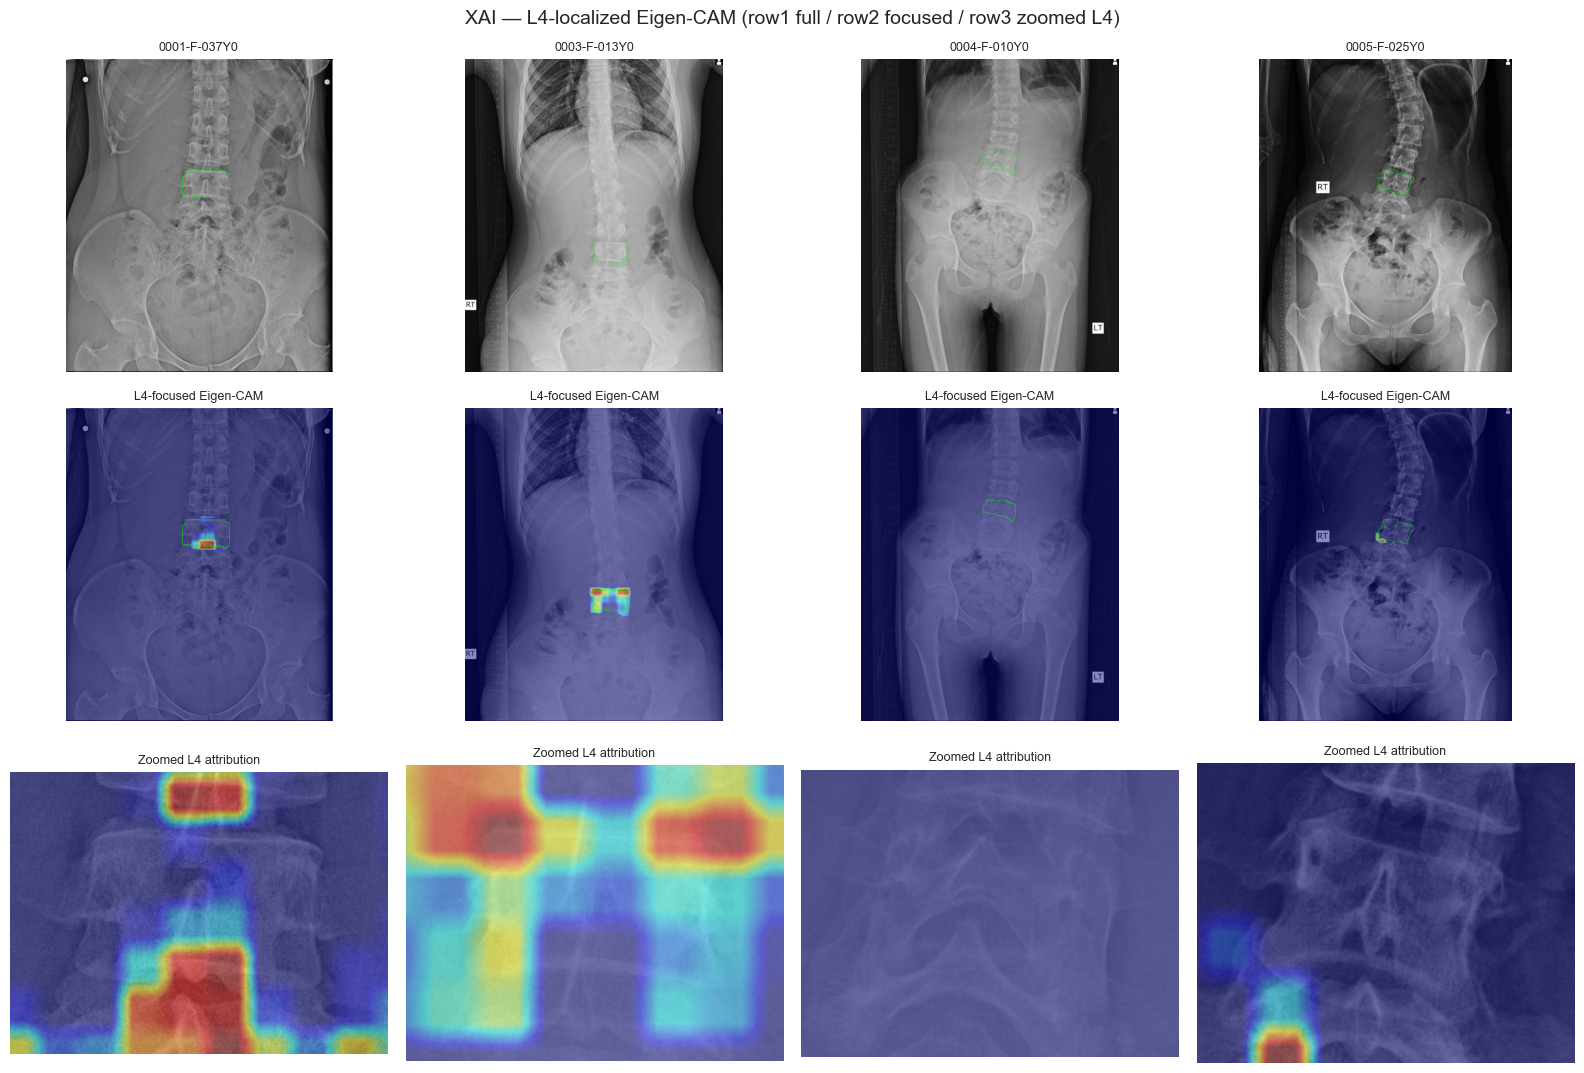

In [12]:
class YOLOEigenCAM:
    '''Gradient-free Eigen-CAM: principal component of a high-res neck activation map.'''
    def __init__(self, model):
        self.caps = {}
        self.handles = []
        layers = model.model.model            # nn.Sequential of YOLO layers
        # hook the last third of the network (neck), where features are semantic yet still spatial
        for idx in range(max(0, len(layers) - 12), len(layers)):
            self.handles.append(layers[idx].register_forward_hook(self._mk(idx)))

    def _mk(self, idx):
        def hook(m, i, o):
            t = o[0] if isinstance(o, (list, tuple)) else o
            if hasattr(t, "ndim") and t.ndim == 4 and t.shape[1] >= 32:
                self.caps[idx] = t.detach()
        return hook

    def __call__(self, rgb):
        self.caps = {}
        _ = seg.predict(rgb, conf=CONF, verbose=False)
        if not self.caps:
            return None
        # choose the activation with the largest spatial area (highest resolution neck output)
        idx = max(self.caps, key=lambda k: self.caps[k].shape[2] * self.caps[k].shape[3])
        A = self.caps[idx][0].cpu().numpy()              # (C, h, w)
        C, h, w = A.shape
        X = A.reshape(C, h * w).T                        # (hw, C)
        X = X - X.mean(0, keepdims=True)
        # first principal component via SVD
        _, _, Vt = np.linalg.svd(X, full_matrices=False)
        cam = (X @ Vt[0]).reshape(h, w)
        if cam.mean() < 0:                               # orient toward strong activations
            cam = -cam
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
        return cam

def l4_focus_weight(mask, ksize=41):
    '''Soft Gaussian weighting around the L4 mask for ROI-focused attribution.'''
    d = cv2.dilate(mask, np.ones((ksize, ksize), np.uint8), iterations=1).astype(np.float32)
    d = cv2.GaussianBlur(d, (ksize, ksize), 0)
    return d / (d.max() + 1e-6)

cammer = YOLOEigenCAM(seg)

# ---- Visualization: focused CAM on the full image + zoomed L4 crop ----
xai_samples = buu_imgs[:4]
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for k, p in enumerate(xai_samples):
    rgb, _, H, W = load_xray(p)
    m, status, r = yolo_l4(rgb)
    cam = cammer(rgb)
    base = rgb.copy()
    # row 0: input with L4 contour
    disp = rgb.copy()
    if m is not None:
        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(disp, cnts, -1, (0, 255, 0), 2)
    axes[0, k].imshow(disp); axes[0, k].set_title(os.path.basename(p)[:12], fontsize=9); axes[0, k].axis("off")

    if cam is None or m is None:
        axes[1, k].imshow(rgb); axes[1, k].axis("off"); axes[1, k].set_title("CAM unavailable", fontsize=9)
        axes[2, k].axis("off"); continue

    cam_full = cv2.resize(cam, (W, H))
    cam_focus = cam_full * l4_focus_weight(m)              # restrict to L4 locality
    cam_focus = cam_focus / (cam_focus.max() + 1e-6)
    heat = cv2.cvtColor(cv2.applyColorMap((cam_focus*255).astype(np.uint8), cv2.COLORMAP_JET),
                        cv2.COLOR_BGR2RGB)
    blend = (0.55*rgb + 0.45*heat).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(blend, cnts, -1, (0, 255, 0), 2)
    axes[1, k].imshow(blend); axes[1, k].set_title("L4-focused Eigen-CAM", fontsize=9); axes[1, k].axis("off")

    # row 2: zoomed L4 crop with (unfocused) CAM to show internal trabecular attribution
    ys, xs = np.where(m > 0)
    pad = int(0.25 * max(np.ptp(ys) + 1, np.ptp(xs) + 1))
    y0, y1 = max(0, ys.min()-pad), min(H, ys.max()+pad)
    x0, x1 = max(0, xs.min()-pad), min(W, xs.max()+pad)
    crop_rgb = rgb[y0:y1, x0:x1]
    crop_cam = cam_full[y0:y1, x0:x1]
    crop_cam = (crop_cam - crop_cam.min()) / (crop_cam.max() - crop_cam.min() + 1e-6)
    crop_heat = cv2.cvtColor(cv2.applyColorMap((crop_cam*255).astype(np.uint8), cv2.COLORMAP_JET),
                             cv2.COLOR_BGR2RGB)
    crop_blend = (0.55*crop_rgb + 0.45*crop_heat).astype(np.uint8)
    axes[2, k].imshow(crop_blend); axes[2, k].set_title("Zoomed L4 attribution", fontsize=9); axes[2, k].axis("off")

fig.suptitle("XAI — L4-localized Eigen-CAM (row1 full / row2 focused / row3 zoomed L4)", fontsize=14)
plt.tight_layout(); plt.show()

## Appendix — (Optional) Re-training YOLOv8-seg from BUU-LSPINE

The model above is pre-trained (`best.pt`). To reproduce it, convert the 4-corner CSV labels to
YOLO-seg polygons and train. **Commented out** by default.

In [13]:
# import shutil
# YOLO_ROOT = "./yolo_ap_seg"; VAL_RATIO = 0.15
# def _rows(path):
#     out=[]
#     for line in open(path):
#         nums=re.findall(r"-?\d+\.?\d*", line)
#         if len(nums)>=4: out.append([float(v) for v in nums[:4]])
#     return out
# def order_quad(pts):
#     pts=sorted(pts,key=lambda p:p[1]); top=sorted(pts[:2],key=lambda p:p[0]); bot=sorted(pts[2:],key=lambda p:p[0])
#     return [top[0],top[1],bot[1],bot[0]]
# def parse_polys(path):
#     rows=_rows(path)
#     if len(rows)<10: return []
#     verts=[]
#     for i in range(5):
#         pts=[]
#         for j in range(2):
#             xL,yL,xR,yR=rows[i*2+j]; pts+=[(xL,yL),(xR,yR)]
#         q=order_quad(pts); verts.append((sum(p[1] for p in q)/4,q))
#     verts.sort(key=lambda v:v[0]); return [q for _,q in verts]
# for sub in ["images/train","images/val","labels/train","labels/val"]:
#     os.makedirs(os.path.join(YOLO_ROOT,sub),exist_ok=True)
# lbls=sorted(glob.glob(os.path.join(LBL_DIR,"*"))); random.shuffle(lbls)
# nv=int(len(lbls)*VAL_RATIO)
# for k,lp in enumerate(lbls):
#     stem=os.path.splitext(os.path.basename(lp))[0]
#     ip=next((os.path.join(IMG_DIR,stem+e) for e in (".jpg",".png") if os.path.exists(os.path.join(IMG_DIR,stem+e))),None)
#     polys=parse_polys(lp)
#     if ip is None or len(polys)!=5: continue
#     im=cv2.imread(ip); H,W=im.shape[:2]; split="val" if k<nv else "train"
#     shutil.copy(ip,os.path.join(YOLO_ROOT,"images",split,os.path.basename(ip)))
#     with open(os.path.join(YOLO_ROOT,"labels",split,stem+".txt"),"w") as f:
#         for cid,q in enumerate(polys):
#             coords=" ".join(f"{x/W:.6f} {y/H:.6f}" for x,y in q); f.write(f"{cid} {coords}\n")
# with open(os.path.join(YOLO_ROOT,"data.yaml"),"w") as f:
#     f.write(f"path: {os.path.abspath(YOLO_ROOT)}\ntrain: images/train\nval: images/val\n")
#     f.write(f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
# YOLO("yolov8n-seg.pt").train(data=os.path.join(YOLO_ROOT,"data.yaml"),
#                              epochs=100, imgsz=640, batch=-1, project="ap_seg", name="l1_l5",
#                              patience=20, workers=0)

## Summary

- **Segmentation:** YOLOv8-seg (instance) with a class/4th-from-top L4 selector — reliable L4 masks.
- **BMD:** linear normalized intensity inside the cancellous L4 ROI (relative proxy; calibrate with a
  phantom/DXA for absolute g/cm²).
- **Microarchitecture:** rotation-averaged GLCM (Contrast, Correlation, Energy/ASM, Homogeneity).
- **Evaluation:** Dice/IoU/Precision/Recall + confusion matrix + Bland-Altman, all on the DICOM test
  set against true L4 masks.
- **XAI:** L4-localized Eigen-CAM — attribution now lands on the L4 body/trabeculae, not background.
- **Swappable design:** the segmenter is a module; the from-scratch ResNet-U-Net lives in v2.